In [2]:
from conda.gateways.connection.download import download
from mpmath import sec
from sympy.core.random import shuffle
from torchvision.datasets import mnist
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

torch.Size([1000, 2])
torch.Size([1000, 1])
epoch 1, loss 0.693618
epoch 2, loss 0.015557
epoch 3, loss 0.000448
epoch 4, loss 0.000108
epoch 5, loss 0.000099
epoch 6, loss 0.000099
epoch 7, loss 0.000099
epoch 8, loss 0.000099
epoch 9, loss 0.000099
epoch 10, loss 0.000099
真实 w: tensor([ 2.0000, -3.4000])
学到 w: tensor([[ 1.9998, -3.3995]])
真实 b: 4.2
学到 b: 4.2001729011535645


In [3]:
trans=transforms.ToTensor()#预处理
mnist_train=torchvision.datasets.FashionMNIST(
    root="../data",train=True,transform=trans,download=True#下载训练集
)
mnist_test=torchvision.datasets.FashionMNIST(
    root="../data",train=False,transform=trans,download=True#下载不用的测试集

)
len(mnist_train),len(mnist_test)

(60000, 10000)

In [4]:
#查看用时
mnist_train[1][0].shape

batch_size=256
def get_dataloader_workers():

    return 4
train_iter=data.DataLoader(mnist_train,batch_size,shuffle=True,
            num_workers=get_dataloader_workers()               )
timer=d2l.Timer()
for x,y in train_iter:
    continue
f'{timer.stop():.2f}sec'

'6.94sec'

In [5]:
def get_dataloader_workers():
    return 4


In [7]:
def load_data_fashion_mnist(batch_size,resize=None):
    trans=[transforms.ToTensor()]#初始化训练集
    if resize :#resize=none
     trans.insert(0,transforms.Resize(resize))#put resize into start
    trans=transforms.Compose(trans)#整合
    mnist_train=torchvision.datasets.FashionMNIST(root="../data",train=True,transform=trans,download=True)#下载训练集
    mnist_test=torchvision.datasets.FashionMNIST(root="../data",train=False,transform=trans,download=True)#下载测试集不用训练
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test,batch_size,shuffle=False,num_workers=get_dataloader_workers()))#加载数据集


In [8]:
def softmax(x):
    x_exp=torch.exp(x)
    partition=x_exp.sum(1,keepdim=True)
    return x_exp/partition    #构建softmax回归函数
x=torch.randn(2,5)
x_prob=softmax(x)
x_prob,x_prob.sum(1)

(tensor([[0.3299, 0.3076, 0.0731, 0.2544, 0.0350],
         [0.2550, 0.5234, 0.0912, 0.0857, 0.0447]]),
 tensor([1.0000, 1.0000]))

In [9]:
def net(X):
    X = X.to(device)
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)#构建模型

In [10]:
y = torch.tensor([0, 2 , 1])#y_hat是数据样本,预测概率y是标签
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5],[0.5,0.8,0.9]])#0，与1
y_hat[[0, 1, 2], y]#一一对应

tensor([0.1000, 0.5000, 0.8000])

In [11]:
def cross_entropy(y_hat,y):
    return  - torch.log(y_hat[range(len(y_hat)),y])
cross_entropy(y_hat,y)#实现交叉熵损失函数

tensor([2.3026, 0.6931])

In [12]:
def accuracy(y_hat,y):#分类
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())

In [13]:
accuracy(y_hat,y)/len(y)

0.5

In [14]:



class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def train_epoch_ch3(net, train_iter, loss, updater):#@save
    if isinstance(net, torch.nn.Module):#如果net应用了torch的模板那么就启动训练模式
        net.train()

    metric = Accumulator(3)#训练损失总和
#预测正确的数量
#样本总数

    for X, y in train_iter:#开始训练
        X, y = X.to(device), y.to(device)#选择使用GPU
        y_hat = net(X)#算预测
        l = loss(y_hat, y)#计算损失函数

        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()#梯度清零
            l.mean().backward()#反向传播（用损失函数平均值）
            updater.step()#内置优化器更新参数
        else:
            l.sum().backward()#反向传播（用损失函数和）
            updater(X.shape[0])# 自定义更新函数，传入批量大小

        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
                         #总损失    #正确的数                #样本总数
    return metric[0] / metric[2], metric[1] / metric[2]


In [15]:
from IPython import display
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


In [16]:
def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


In [17]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [18]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

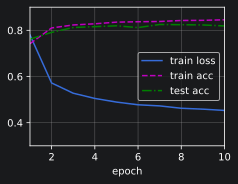

In [19]:
train_iter, test_iter = load_data_fashion_mnist(256, resize=32)
#可以自动匹配下，图片的大小
for X, y in train_iter:
    print(X.shape)
    break

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_inputs = X[0].numel()
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs),
                 device=device, requires_grad=True)
b = torch.zeros(num_outputs, device=device, requires_grad=True)

num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

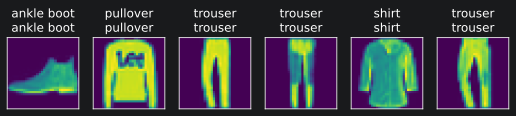

In [20]:
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1).cuda())
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    h, w = X.shape[2], X.shape[3]
    d2l.show_images(
        X[0:n].reshape((n, h, w)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)